In [ ]:
import pennylane as qml
import torch
import matplotlib.pyplot as plt

from pennylane import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

from qiskit import QuantumCircuit
from qiskit.circuit.library import zz_feature_map, n_local
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

In [20]:
SEED = 42 # For reproducibility
torch.manual_seed(SEED)

# Hybrid Quantum Neural Networks

So far, we have used the word hybrid to describe algorithms that combine classical and quantum computation, such as VQE, QAOA, QSVMs or QNN training. However, in this notebook we will use the term in a more specific way. A hybrid architecture refers to a model in which classical neural network layers and quantum neural network layers are connected and trained together as a single unit.

The main idea is to insert a quantum layer inside a classical neural network. This quantum layer receives a numerical array as input, usually coming from a previous classical layer, processes it through a parametrized quantum circuit, and returns a classical output obtained from quantum measurements. From the point of view of the next classical layer, the quantum layer behaves like an ordinary layer with a fixed number of output neurons.

A simple hybrid QNN could be structured as follows. First, the model receives a classical input vector. Then, one or more classical layers transform this input, possibly reducing its dimensionality. The resulting vector is passed to a quantum layer, where the data are encoded into a quantum state, processed by a variational circuit, and measured. Finally, the measured outputs can be passed to another classical layer to produce the final prediction.

This type of architecture is especially useful when the original dataset has more features than can be directly handled by a small quantum circuit. Instead of applying dimensionality reduction as a separate preprocessing step, a classical neural network can learn an internal representation of the data and feed it into the quantum layer. Since the whole model is trained jointly, both the classical and quantum parts contribute to the final task.

However, quantum layers should not be added blindly. They are not guaranteed to improve the performance of a classical model, and in some cases they may even make training harder. The design must be intentional: the number of qubits, the feature map, the variational ansatz, the measurement strategy and the connection with the classical layers all affect the model's behavior. For example, if the quantum feature map expects normalized inputs, the previous classical layer should use an activation function compatible with that range.

In this notebook, we will build and train hybrid quantum neural networks for classification tasks. The goal is to understand how classical and quantum layers can be combined, how the complete model is optimized, and whether the hybrid architecture can provide useful performance on real datasets.


# Binary classification problem

First, we will work on a binary classification problem using an artificial dataset generated by the function `make_clasiffication` from `sklearn.datasets`.

In [21]:
x, y = make_classification(n_samples=1000, n_features=20)

x_tr, x_test, y_tr, y_test = train_test_split(x, y, test_size=0.2)
x_test, x_val, y_test, y_val = train_test_split(x_test, y_test, test_size=0.5)

# Convert data to torch tensors
x_train_t = torch.from_numpy(x_tr).double()
y_train_t = torch.from_numpy(y_tr).double()

x_val_t = torch.from_numpy(x_val).double()
y_val_t = torch.from_numpy(y_val).double()

x_test_t = torch.from_numpy(x_test).double()
y_test_t = torch.from_numpy(y_test).double()

# Load data
train_dataset = TensorDataset(x_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)

In [22]:
def TwoLocalPennyLane(nqubits: int, theta: list[float], reps: int) -> None:
    """
    Builds a two-local variational ansatz using PennyLane.
    """
    # Initial rotation layer
    for i in range(nqubits):
        qml.RY(theta[i], wires=i)

    # Entangling and rotation layers
    for rep in range(reps):
        # Linear CNOT entanglement
        for i in range(nqubits-1):
            qml.CNOT(wires = [i, i+1])
        # New rotation layer
        for i in range(nqubits):
            qml.RY(theta[i+(rep+1)*nqubits], wires=i)

In [23]:
nqubits = 4
nreps = 2
dev = qml.device("lightning.qubit", wires=nqubits)

def qnn_circ(inputs: list[float], theta: list[float]) -> None:
    """
    Builds a QNN circuit in Pennylane using angle encoding, a Two local ansantz
    and the observable M = |0><0| for the measurement.
    """
    qml.AngleEmbedding(inputs, wires=range(nqubits))
    TwoLocalPennyLane(nqubits, theta, nreps)
    return qml.expval(qml.Projector([0], wires=0))

qnn = qml.QNode(
    func=qnn_circ,
    device=dev,
    interface="torch",
    diff_method="adjoint"
)

In [24]:
weights = {"theta": ((nreps + 1) * nqubits,)}
qlayer = qml.qnn.TorchLayer(qnn, weights)

# Build the PyTorch model
model = torch.nn.Sequential(
    torch.nn.Linear(20, 16),
    torch.nn.Sigmoid(),
    torch.nn.Linear(16, 8),
    torch.nn.Sigmoid(),
    torch.nn.Linear(8, 4),
    torch.nn.Sigmoid(),
    qlayer
)

model.double()

# Training loop with early stopping
epochs = 100
lr = 0.005
patience = 4
patience_counter = 0
best_state = None
best_val_loss = float("inf")

# Define optimizer and loss function
opt = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = torch.nn.BCELoss()

history = {"loss": [], "val_loss": []}

for epoch in range(epochs):
    model.train()
    loss_list = []
    for xb, yb in train_loader:
        opt.zero_grad()
        pred = model(xb).reshape(-1)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()
        loss_list.append(loss.item())
    
    model.eval()
    with torch.no_grad():
        pred_val = model(x_val_t)
        val_loss = loss_fn(pred_val, y_val_t).item()
    
    loss = sum(loss_list) / len(loss_list)

    history["loss"].append(loss)
    history["val_loss"].append(val_loss)

    if epoch % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1}: "
            f"loss={loss:.4f}, "
            f"val_loss={val_loss:.4f}"
        )

    if val_loss <= best_val_loss:
        best_val_loss = val_loss
        best_state = {
            name : param.detach().clone()
            for name, param in model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print("Early Stopping")
        break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 1: loss=0.8558, val_loss=0.7786
Epoch 6: loss=0.6888, val_loss=0.6936
Epoch 11: loss=0.4876, val_loss=0.4959
Epoch 16: loss=0.4282, val_loss=0.4652
Epoch 21: loss=0.4172, val_loss=0.4509
Epoch 26: loss=0.4103, val_loss=0.4474
Early Stopping


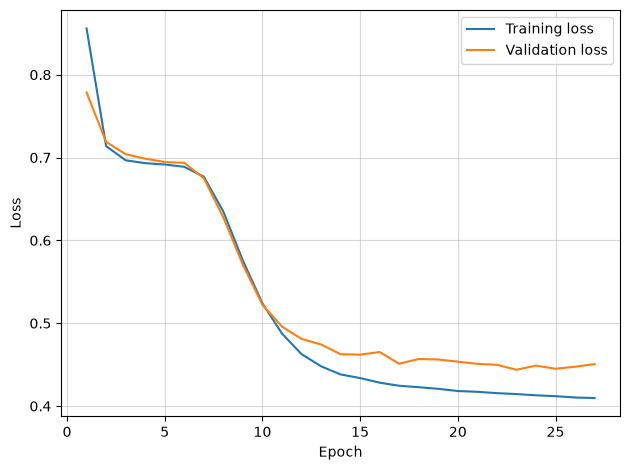

In [25]:
def plot_losses(history) -> None:
    """
    Plots the training and validation curves from the history of a model
    """
    tr_loss = history["loss"]
    val_loss = history["val_loss"]
    epochs = np.array(range(len(tr_loss))) + 1
    plt.plot(epochs, tr_loss, label="Training loss")
    plt.plot(epochs, val_loss, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_losses(history)

In [26]:
# Evaluate the precision of the model in all the datasets
model.eval()
with torch.no_grad():
    train_probs = model(x_train_t).squeeze()
    train_preds = (train_probs >= 0.5).double()
    train_acc = (train_preds == y_train_t).double().mean().item()

    val_probs = model(x_val_t).squeeze()
    val_preds = (val_probs >= 0.5).double()
    val_acc = (val_preds == y_val_t).double().mean().item()

    test_probs = model(x_test_t).squeeze()
    test_preds = (test_probs >= 0.5).double()
    test_acc = (test_preds == y_test_t).double().mean().item()

print(f"Train accuracy: {100*train_acc:.2f}%")
print(f"Val accuracy: {100*val_acc:.2f}%")
print(f"Test accuracy: {100*test_acc:.2f}%")

Train accuracy: 91.50%
Val accuracy: 88.00%
Test accuracy: 88.00%


We get very solid results with accuracies close to 90% in all three datasets and no clear signs of offerfitting.

# Multi-class classification problem

In [30]:
x, y = make_classification(
    n_samples=2000, 
    n_features=20, 
    n_classes=3, 
    n_clusters_per_class=1
)

x_tr, x_test, y_tr, y_test = train_test_split(x, y, train_size=0.8)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, train_size=0.5)

# Convert data to torch tensors
x_train_t = torch.from_numpy(x_tr).double()
y_train_t = torch.from_numpy(y_tr).long()

x_val_t = torch.from_numpy(x_val).double()
y_val_t = torch.from_numpy(y_val).long()

x_test_t = torch.from_numpy(x_test).double()
y_test_t = torch.from_numpy(y_test).long()

# Load data
train_dataset = TensorDataset(x_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)

In [ ]:
def TwoLocalPennyLane(nqubits: int, theta: list[float], reps: int) -> None:
    """
    Builds a two-local variational ansatz using PennyLane.
    """
    # Initial rotation layer
    for i in range(nqubits):
        qml.RY(theta[i], wires=i)

    # Entangling and rotation layers
    for rep in range(reps):
        # Linear CNOT entanglement
        for i in range(nqubits-1):
            qml.CNOT(wires = [i, i+1])
        # New rotation layer
        for i in range(nqubits):
            qml.RY(theta[i+(rep+1)*nqubits], wires=i)

In [ ]:
nqubits = 4
nreps = 2
dev = qml.device("lightning.qubit", wires=nqubits)

def qnn_circ(inputs: list[float], theta: list[float]) -> None:
    """
    Builds a QNN circuit in Pennylane using angle encoding, a Two local ansantz
    and the observable M = |0><0| in the first 3 qubitsfor the measurement.
    """
    qml.AngleEmbedding(inputs, wires=range(nqubits))
    TwoLocalPennyLane(nqubits, theta, nreps)
    return [qml.expval(qml.Projector([0], wires=0)),
            qml.expval(qml.Projector([0], wires=1)),
            qml.expval(qml.Projector([0], wires=2))]

qnn = qml.QNode(
    func=qnn_circ,
    device=dev,
    interface="torch",
    diff_method="adjoint"
)

In [33]:
weights = {"theta": ((nreps + 1) * nqubits,)}
qlayer = qml.qnn.TorchLayer(qnn, weights)

# Build the PyTorch model
model = torch.nn.Sequential(
    torch.nn.Linear(20, 8),
    torch.nn.ELU(),
    torch.nn.Linear(8, 4),
    torch.nn.Sigmoid(),
    qlayer
)
# IMPORTANT: When using CrossEntropyLoss, we don't need to apply a softmax activation function 
# at the end of the model, as CrossEntropyLoss combines LogSoftmax and NLLLoss in one single class. 

model.double()

# Training loop with early stopping
epochs = 150
lr = 0.001
patience = 3
patience_counter = 0
best_state = None
best_val_loss = float("inf")


# Define optimizer and loss function
opt = torch.optim.Adam(params=model.parameters(), lr=lr)
loss_fn = torch.nn.CrossEntropyLoss()

history = {"loss": [], "val_loss": []}

for epoch in range(epochs):
    model.train()
    loss_list = []

    for xb, yb in train_loader:
        opt.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()
        loss_list.append(loss.item())
    
    model.eval()
    with torch.no_grad():
        val_pred = model(x_val_t)
        val_loss = loss_fn(val_pred, y_val_t).item()
    
    loss = sum(loss_list) / len(loss_list)

    history["loss"].append(loss)
    history["val_loss"].append(val_loss)

    if epoch % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1}: "
            f"loss={loss:.4f}, "
            f"val_loss={val_loss:.4f}"
        )

    if val_loss <= best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {
            name: params.detach().clone()
            for name, params in model.state_dict().items()
        }
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print("Early stop")
        break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 1: loss=1.1102, val_loss=1.1062
Epoch 6: loss=1.0010, val_loss=1.0055
Epoch 11: loss=0.9628, val_loss=0.9744
Epoch 16: loss=0.9525, val_loss=0.9653
Epoch 21: loss=0.9478, val_loss=0.9613
Epoch 26: loss=0.9443, val_loss=0.9585
Epoch 31: loss=0.9400, val_loss=0.9546
Epoch 36: loss=0.9357, val_loss=0.9511
Epoch 41: loss=0.9323, val_loss=0.9485
Epoch 46: loss=0.9303, val_loss=0.9476
Epoch 51: loss=0.9293, val_loss=0.9473
Epoch 56: loss=0.9286, val_loss=0.9471
Epoch 61: loss=0.9279, val_loss=0.9469
Epoch 66: loss=0.9271, val_loss=0.9465
Epoch 71: loss=0.9263, val_loss=0.9460
Epoch 76: loss=0.9256, val_loss=0.9461
Early stop


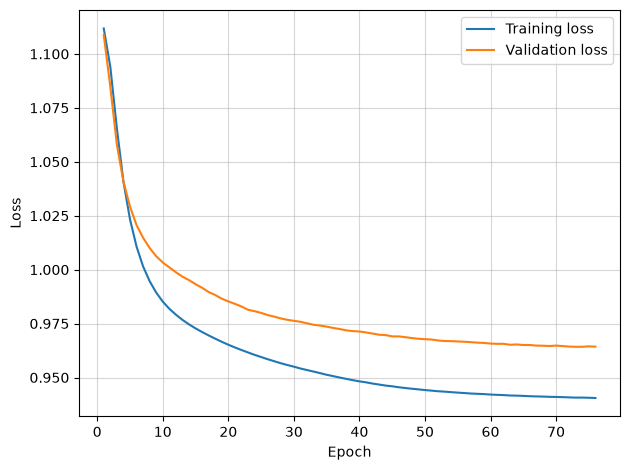

In [ ]:
def plot_losses(history) -> None:
    """
    Plots the training and validation curves from the history of a model
    """
    tr_loss = history["loss"]
    val_loss = history["val_loss"]
    epochs = np.array(range(len(tr_loss))) + 1
    plt.plot(epochs, tr_loss, label="Training loss")
    plt.plot(epochs, val_loss, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_losses(history)

In [ ]:
model.eval()
with torch.no_grad():
    tr_pred = torch.argmax(model(x_train_t), dim=1)
    tr_acc = (tr_pred == y_train_t).double().mean()
    test_pred = torch.argmax(model(x_test_t), dim=1)
    test_acc = (test_pred == y_test_t).double().mean()
    val_pred = torch.argmax(model(x_val_t), dim=1)
    val_acc = (val_pred == y_val_t).double().mean()


print(f"Train accuracy: {100*tr_acc:.2f}%")
print(f"Test accuracy: {100*test_acc:.2f}%")
print(f"Val accuracy: {100*val_acc:.2f}%")

Train accuracy: 93.62%
Test accuracy: 91.50%
Val accuracy: 85.50%


Again, we get really solid results without signs of overfitting.

# Binary classifier using Qiskit

In [15]:
n_features = 20

x, y = make_classification(n_samples=1000, n_features=n_features)

x_tr, x_test, y_tr, y_test = train_test_split(x, y, test_size=0.2)
x_test, x_val, y_test, y_val = train_test_split(x_test, y_test, test_size=0.5)

# Convert data to torch tensors
x_train_t = torch.from_numpy(x_tr).float()
y_train_t = torch.from_numpy(y_tr).float().view(-1, 1)

x_val_t = torch.from_numpy(x_val).float()
y_val_t = torch.from_numpy(y_val).float().view(-1, 1)

x_test_t = torch.from_numpy(x_test).float()
y_test_t = torch.from_numpy(y_test).float().view(-1, 1)

# Load data
train_dataset = TensorDataset(x_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)

In [ ]:
nqubits = 4

zz_fm = zz_feature_map(feature_dimension=nqubits)

twolocal = n_local(
    num_qubits=nqubits,
    rotation_blocks=["ry", "rz"],
    entanglement_blocks="cz",
    entanglement="linear",
    reps=1
)

qc = QuantumCircuit(nqubits)
qc.compose(zz_fm, inplace=True)
qc.compose(twolocal, inplace=True)

input_params = list(zz_fm.parameters)
weight_params = list(twolocal.parameters)

In this section, we'll subclass `nn.Module` rather than using `nn.Sequential` to gain more flexibility, at the expense of having to write more code.

In [17]:
class HybridQNN(torch.nn.Module):
    def __init__(self):
        super(HybridQNN, self).__init__()

        qnn = EstimatorQNN(
            circuit=qc,
            input_params=input_params,
            weight_params=weight_params,
            input_gradients=True,        )
        self.linear1 = torch.nn.Linear(n_features, nqubits)
        self.qlayer = TorchConnector(qnn)
        self.linear2 = torch.nn.Linear(1, 1)
    
    def forward(self, x):
        x = self.linear1(x)
        x = torch.sigmoid(x)
        x = self.qlayer(x)
        x = self.linear2(x)
        x = torch.sigmoid(x)
        return x 

model = HybridQNN()
model.float()

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


HybridQNN(
  (linear1): Linear(in_features=20, out_features=4, bias=True)
  (qlayer): TorchConnector()
  (linear2): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
# Training loop with early stopping
epochs = 150
lr = 0.001
patience = 3
patience_counter = 0
best_state = None
best_val_loss = float("inf")


# Define optimizer and loss function
opt = torch.optim.Adam(params=model.parameters(), lr=lr)
loss_fn = torch.nn.BCELoss()

history = {"loss": [], "val_loss": []}

for epoch in range(epochs):
    model.train()
    loss_list = []

    for xb, yb in train_loader:
        opt.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb).view(-1, 1)
        loss.backward()
        opt.step()
        loss_list.append(loss.item())
    
    model.eval()
    with torch.no_grad():
        val_pred = model(x_val_t)
        val_loss = loss_fn(val_pred, y_val_t).item()
    
    loss = sum(loss_list) / len(loss_list)

    history["loss"].append(loss)
    history["val_loss"].append(val_loss)

    if epoch % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1}: "
            f"loss={loss:.4f}, "
            f"val_loss={val_loss:.4f}"
        )

    if val_loss <= best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {
            name: params.detach().clone()
            for name, params in model.state_dict().items()
        }
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print("Early stop")
        break

if best_state is not None:
    model.load_state_dict(best_state)

In [ ]:
model.eval()

with torch.no_grad():
    train_probs = model(x_train_t.float())
    train_acc_pred = (train_probs >= 0.5).int()
    train_acc = (train_acc_pred == y_train_t.int()).float().mean().item()

    test_probs = model(x_test_t.float())
    test_acc_pred = (test_probs >= 0.5).int()
    test_acc = (test_acc_pred == y_test_t.int()).float().mean().item()

    val_probs = model(x_val_t.float())
    val_acc_pred = (val_probs >= 0.5).int()
    val_acc = (val_acc_pred == y_val_t.int()).float().mean().item()

print(f"Train accuracy: {100 * train_acc:.2f}%")
print(f"Test accuracy: {100 * test_acc:.2f}%")
print(f"Val accuracy: {100 * val_acc:.2f}%")

When using Qiskit instead of PennyLane, the executions take much longer. For that reason, we will not get the results of this last part, even though we expect them to be very similar to the ones obtained before.